# Task 6: Term Deposit Subscription Prediction (Bank Marketing)

**DevelopersHub Corporation — Data Science & Analytics Internship**

## Problem Statement
Banks run costly outbound marketing campaigns (phone calls) to convince customers to
subscribe to a **term deposit**. Calling every customer is expensive and inefficient.
If we can predict *in advance* which customers are likely to say "yes", the bank can
focus its calling effort on the highest-probability leads, cutting cost and improving
conversion rates.

## Objective
Build and evaluate classification models that predict whether a customer will subscribe
to a term deposit (`y` = yes/no) as a result of a marketing campaign, using the
**Bank Marketing Dataset (UCI Machine Learning Repository)**. We will also use **SHAP**
to explain individual model predictions (Explainable AI).

## Plan
1. Load and explore the dataset
2. Data cleaning & preprocessing
3. Encode categorical features
4. Exploratory Data Analysis (EDA)
5. Train classification models (Logistic Regression, Random Forest)
6. Evaluate with Confusion Matrix, F1-Score, ROC Curve
7. Explain predictions with SHAP (at least 5 individual predictions)
8. Conclusion & business insights


## 1. Imports

In [1]:
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, f1_score,
                              roc_auc_score, roc_curve)

# SHAP is used for model explainability 
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


## 2. Load and Explore the Dataset

In [4]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Internship DA\bank-full.csv", sep=';')
print(f"Shape: {df.shape}")
df.head()


Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [10]:
# Check for missing / null values
print("Missing values per column:")
print(df.isnull().sum())

# The dataset encodes "unknown" as a category instead of NaN in several columns.
# Let's see where "unknown" shows up.
for col in df.select_dtypes(include='object').columns:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} 'unknown' values ({n_unknown/len(df)*100:.1f}%)")


Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
job: 288 'unknown' values (0.6%)
education: 1857 'unknown' values (4.1%)
contact: 13020 'unknown' values (28.8%)
poutcome: 36959 'unknown' values (81.7%)


In [11]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Target class balance
print("\nTarget distribution:")
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).round(3))


Duplicate rows: 0

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64
y
no     0.883
yes    0.117
Name: proportion, dtype: float64


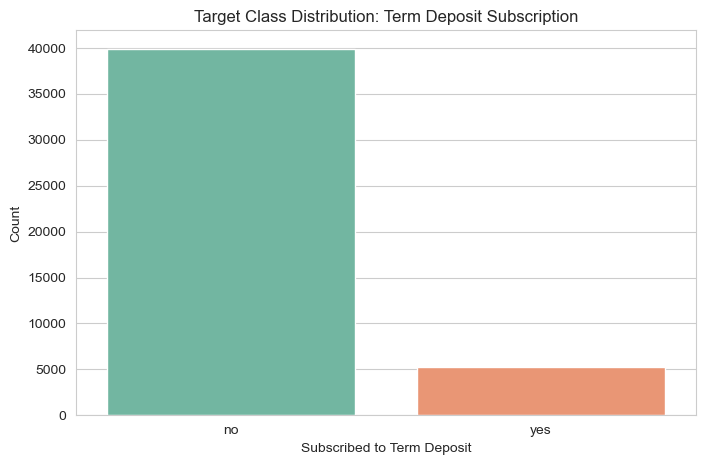

In [9]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='y', hue='y', palette='Set2', legend=False, ax=ax)
ax.set_title('Target Class Distribution: Term Deposit Subscription')
ax.set_xlabel('Subscribed to Term Deposit')
ax.set_ylabel('Count')
plt.show()


## 3. Data Cleaning & Preprocessing

**Observations:**
- There are no true `NaN` values, but several categorical columns (`job`, `education`,
  `contact`, `poutcome`) use the literal category `"unknown"` in place of missing data.
  Rather than dropping these rows (which would lose ~30% of records for `poutcome`), we
  keep `"unknown"` as its own category — it is still informative signal for the model.
- `pdays == -1` means the customer was never contacted before a previous campaign. We
  keep this as-is since it's meaningful, but flag it as a separate binary feature too.
- The target class is imbalanced (~88% "no" vs ~12% "yes"), which we handle with
  `class_weight='balanced'` in our models and by looking at F1-score / ROC-AUC rather
  than accuracy alone.

In [12]:
df_clean = df.copy()

# Flag whether the customer was previously contacted (pdays == -1 means "never")
df_clean['was_previously_contacted'] = (df_clean['pdays'] != -1).astype(int)

# No rows are dropped -- "unknown" categories are retained as meaningful information.
print(f"Cleaned dataset shape: {df_clean.shape}")
df_clean.head()


Cleaned dataset shape: (45211, 18)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,was_previously_contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


## 4. Encode Categorical Features

All categorical (object/string) columns are label-encoded so they can be consumed by
scikit-learn models. We keep a dictionary of fitted encoders so we can map encoded
values back to their original labels later (useful for SHAP explanations).

In [14]:
df_enc = df_clean.copy()

# Encode the target: no -> 0, yes -> 1
target_encoder = LabelEncoder()
df_enc['y'] = target_encoder.fit_transform(df_enc['y'])
print("Target classes:", list(target_encoder.classes_), "-> [0, 1]")

# Encode all remaining categorical (object/string) features
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

df_enc.head()


Target classes: ['no', 'yes'] -> [0, 1]
Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,was_previously_contacted
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0,0


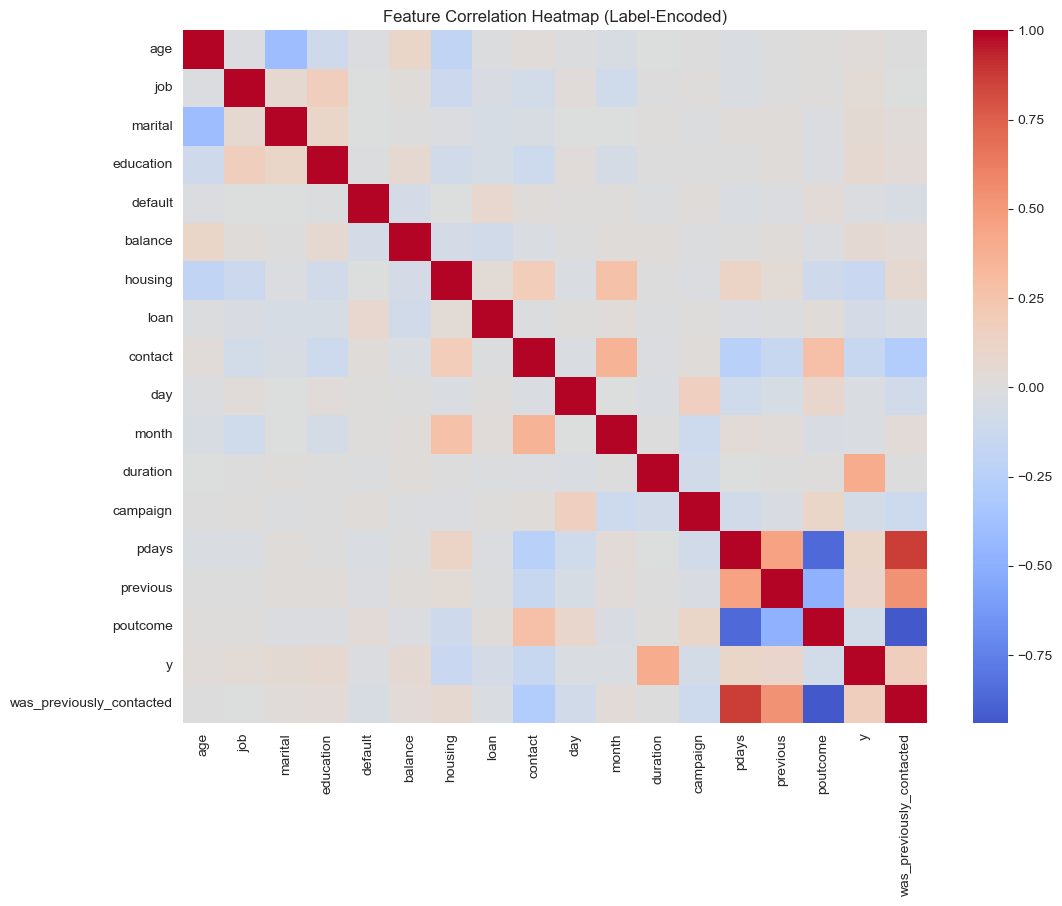

In [15]:
# Quick correlation check on the fully-numeric encoded dataframe
plt.figure(figsize=(12, 9))
sns.heatmap(df_enc.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Heatmap (Label-Encoded)')
plt.show()


## 5. Exploratory Data Analysis (EDA)

A few targeted views into how customer attributes relate to subscription behavior.

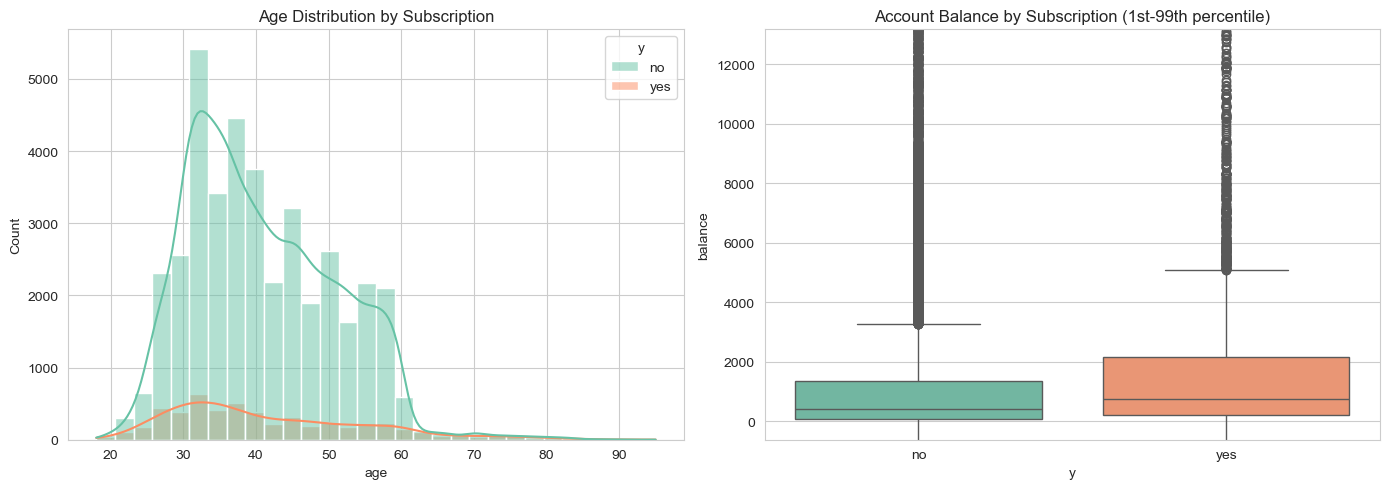

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_clean, x='age', hue='y', bins=30, kde=True, ax=axes[0], palette='Set2')
axes[0].set_title('Age Distribution by Subscription')

sns.boxplot(data=df_clean, x='y', y='balance', hue='y', ax=axes[1], palette='Set2', legend=False)
axes[1].set_ylim(df_clean['balance'].quantile(0.01), df_clean['balance'].quantile(0.99))
axes[1].set_title('Account Balance by Subscription (1st-99th percentile)')

plt.tight_layout()
plt.show()


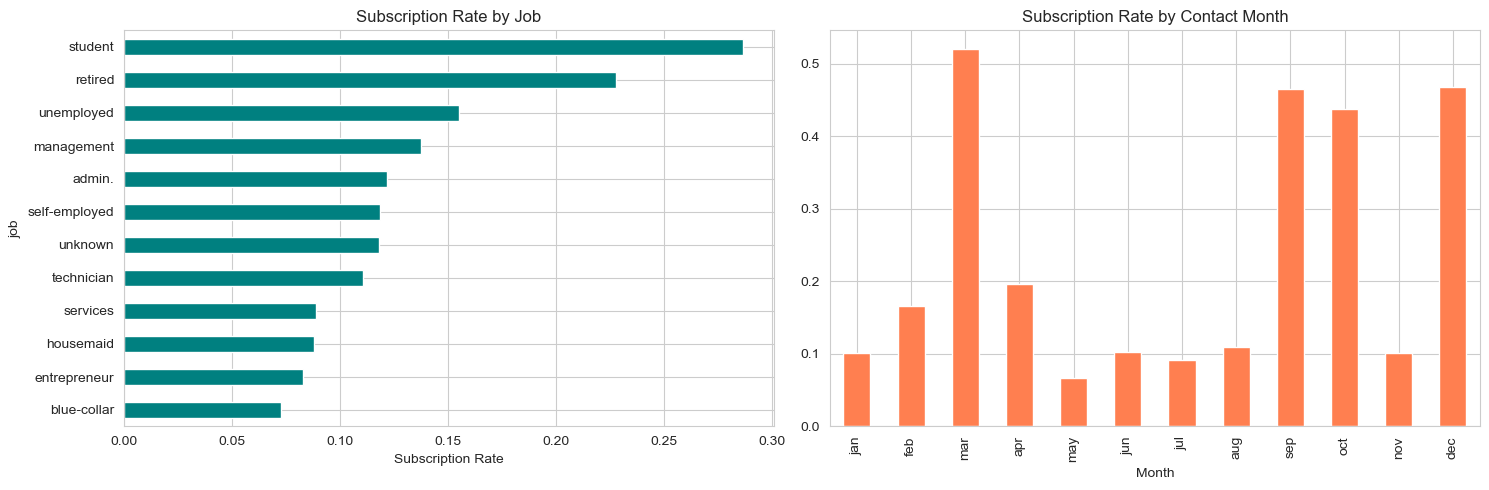

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

job_rate = df_clean.groupby('job')['y'].apply(lambda s: (s == 'yes').mean()).sort_values()
job_rate.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Subscription Rate by Job')
axes[0].set_xlabel('Subscription Rate')

month_rate = df_clean.groupby('month')['y'].apply(lambda s: (s == 'yes').mean())
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])
month_rate.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Subscription Rate by Contact Month')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()


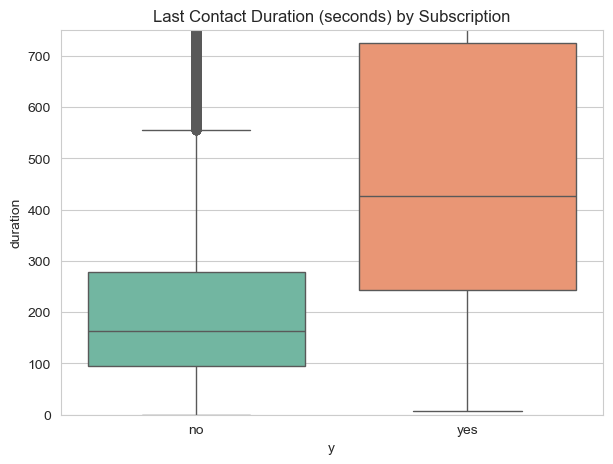

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_clean, x='y', y='duration', hue='y', ax=ax, palette='Set2', legend=False)
ax.set_ylim(0, df_clean['duration'].quantile(0.95))
ax.set_title('Last Contact Duration (seconds) by Subscription')
plt.show()


## 6. Train / Test Split

We use an 80/20 stratified split so the (imbalanced) target proportions are preserved
in both sets.

In [19]:
X = df_enc.drop('y', axis=1)
y = df_enc['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")


Train shape: (36168, 17), Test shape: (9043, 17)
Train positive rate: 0.117, Test positive rate: 0.117


## 7. Train Classification Models

We train two models as requested:
1. **Logistic Regression** — a simple, interpretable linear baseline (features scaled first)
2. **Random Forest** — a stronger non-linear ensemble model

Both use `class_weight='balanced'` to counteract the ~88/12 class imbalance.

In [20]:
# Logistic Regression needs scaled features to converge reliably and fairly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")


Logistic Regression trained.


In [21]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest trained.")


Random Forest trained.


## 8. Model Evaluation: Confusion Matrix, F1-Score, ROC Curve

In [22]:
results = {}

for name, y_pred, y_proba in [
    ('Logistic Regression', y_pred_lr, y_proba_lr),
    ('Random Forest', y_pred_rf, y_proba_rf),
]:
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'f1': f1, 'roc_auc': auc}
    print(f"=== {name} ===")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
    print("-" * 60)

pd.DataFrame(results).T


=== Logistic Regression ===
F1-Score : 0.5161
ROC-AUC  : 0.8886
              precision    recall  f1-score   support

          no       0.97      0.83      0.89      7985
         yes       0.38      0.79      0.52      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.81      0.71      9043
weighted avg       0.90      0.83      0.85      9043

------------------------------------------------------------
=== Random Forest ===
F1-Score : 0.5813
ROC-AUC  : 0.9213
              precision    recall  f1-score   support

          no       0.97      0.87      0.92      7985
         yes       0.45      0.82      0.58      1058

    accuracy                           0.86      9043
   macro avg       0.71      0.85      0.75      9043
weighted avg       0.91      0.86      0.88      9043

------------------------------------------------------------


,f1,roc_auc
Logistic Regression,0.516069,0.888593
Random Forest,0.581333,0.921272


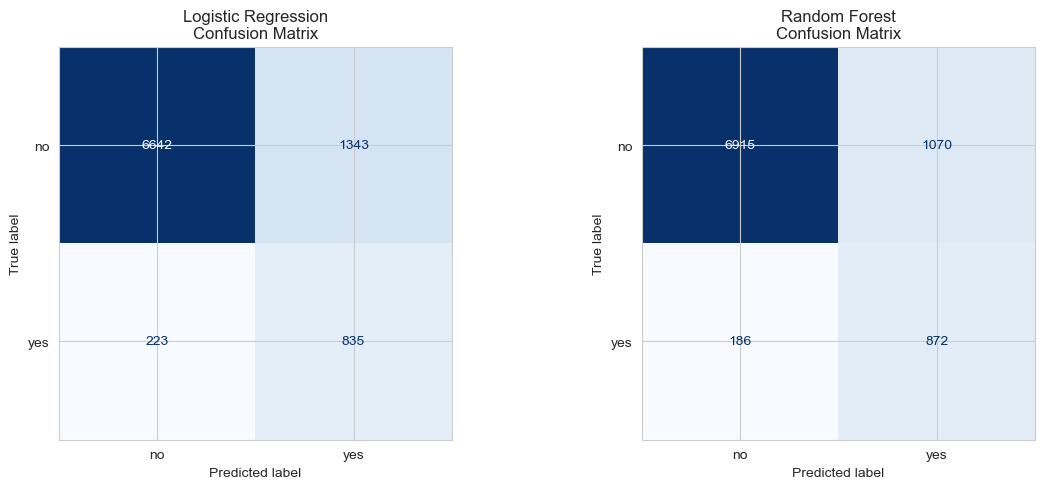

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, y_pred in zip(axes, ['Logistic Regression', 'Random Forest'], [y_pred_lr, y_pred_rf]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nConfusion Matrix')

plt.tight_layout()
plt.show()


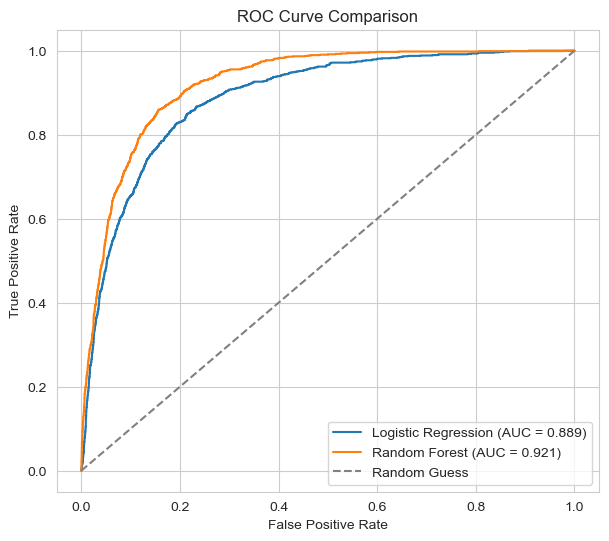

In [24]:
plt.figure(figsize=(7, 6))

for y_proba, name in [(y_proba_lr, 'Logistic Regression'), (y_proba_rf, 'Random Forest')]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()


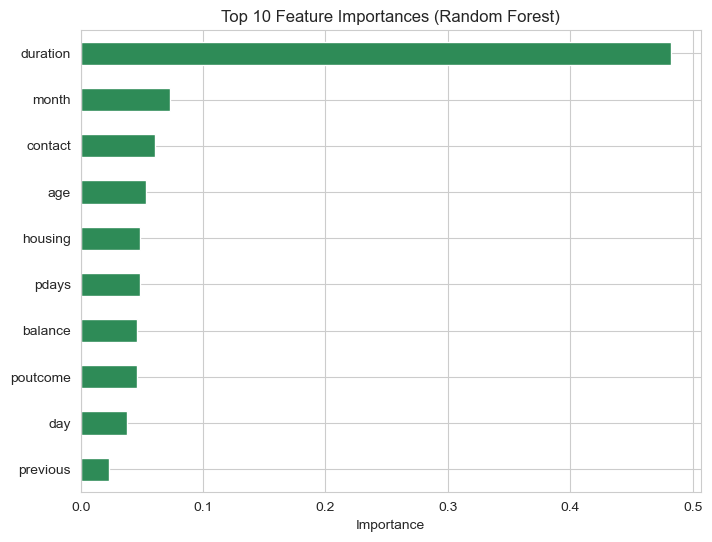

duration    0.482241
month       0.072655
contact     0.060479
age         0.053627
housing     0.048449
pdays       0.048346
balance     0.046259
poutcome    0.045865
day         0.038112
previous    0.023274
dtype: float64

In [25]:
# Feature importance from the Random Forest (a quick sanity check ahead of SHAP)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

importances.head(10)


## 9. Explainable AI (XAI) with SHAP

We use **SHAP (SHapley Additive exPlanations)** on the Random Forest model (our
best-performing model) to explain individual predictions. SHAP values show how much
each feature pushed a specific prediction above or below the average model output.

We explain **5 individual customer predictions** from the test set below.

In [27]:
# Build a SHAP explainer for the tree-based Random Forest model
explainer = shap.TreeExplainer(rf)

# Take a manageable sample of the test set for fast SHAP computation
X_test_sample = X_test.sample(200, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_test_sample)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
    expected_value = explainer.expected_value[1]
elif shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
    expected_value = explainer.expected_value[1]
else:
    shap_values_pos = shap_values
    expected_value = explainer.expected_value

print("SHAP values computed for", X_test_sample.shape[0], "samples.")


SHAP values computed for 200 samples.


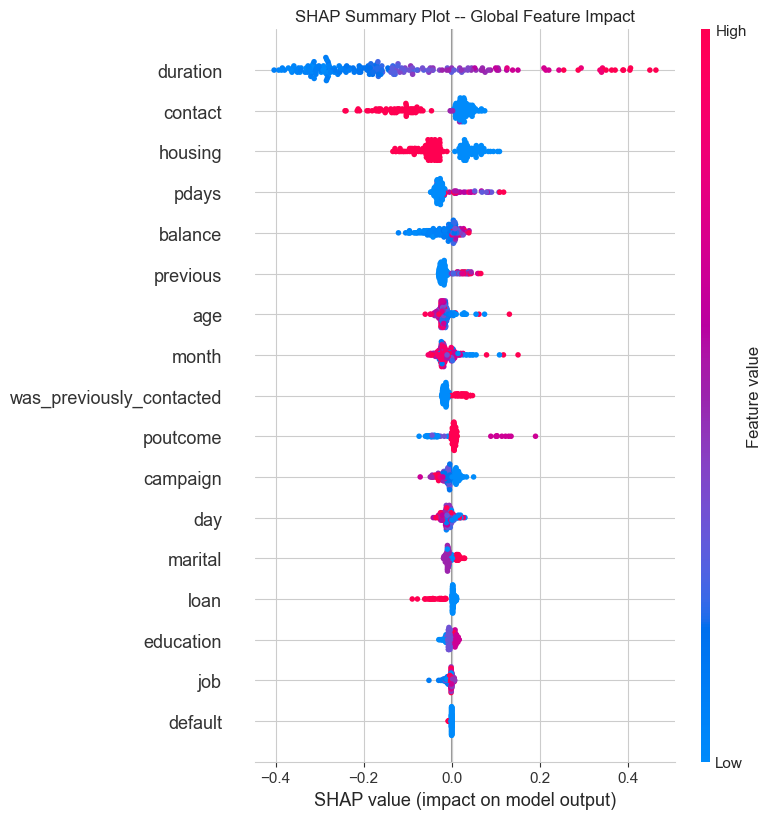

In [28]:
# Global summary: which features matter most across all sampled predictions
shap.summary_plot(shap_values_pos, X_test_sample, show=False)
plt.title('SHAP Summary Plot -- Global Feature Impact')
plt.tight_layout()
plt.show()



--- Prediction #1 (customer index 21198) ---
Predicted probability of subscribing: 0.553
Actual outcome: no


<Figure size 800x500 with 0 Axes>

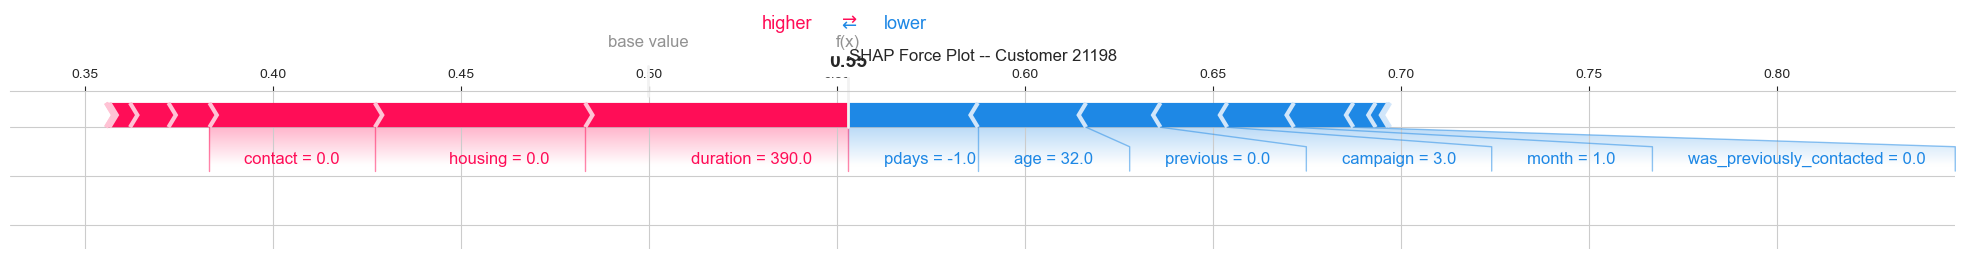


--- Prediction #2 (customer index 22128) ---
Predicted probability of subscribing: 0.146
Actual outcome: no


<Figure size 800x500 with 0 Axes>

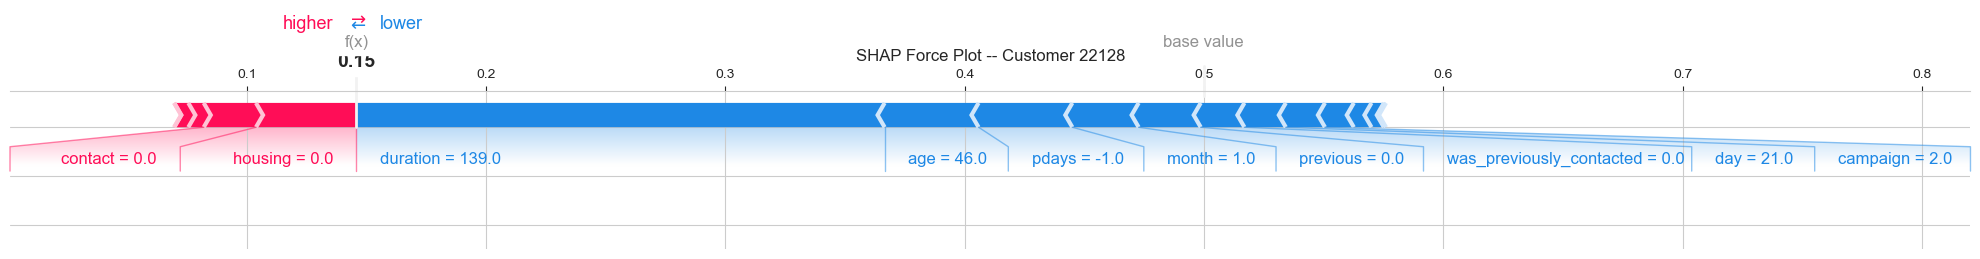


--- Prediction #3 (customer index 31281) ---
Predicted probability of subscribing: 0.868
Actual outcome: yes


<Figure size 800x500 with 0 Axes>

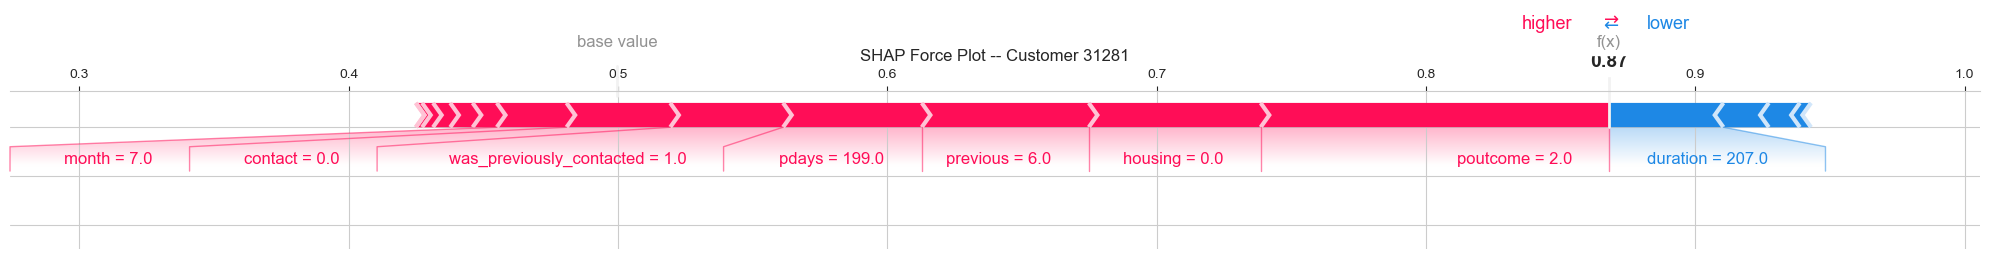


--- Prediction #4 (customer index 39264) ---
Predicted probability of subscribing: 0.022
Actual outcome: no


<Figure size 800x500 with 0 Axes>

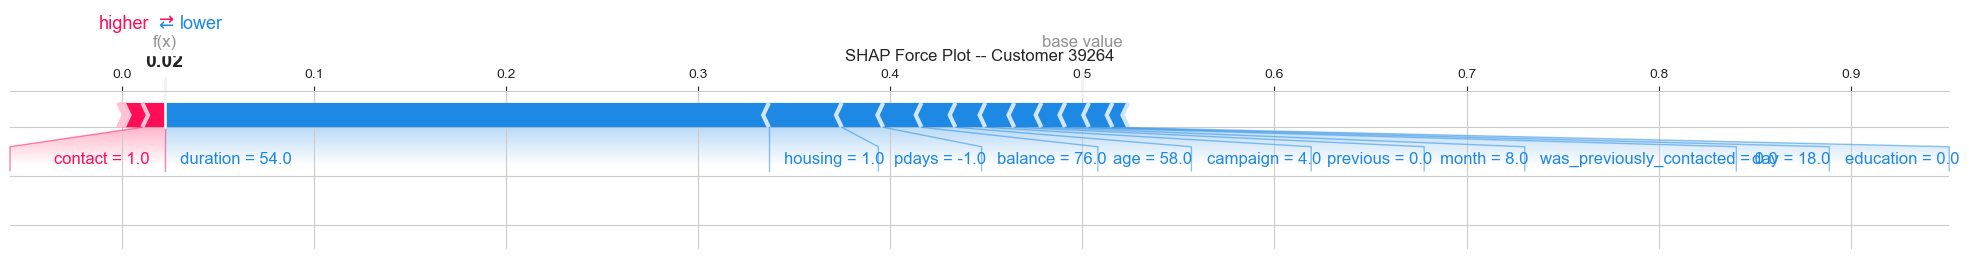


--- Prediction #5 (customer index 10830) ---
Predicted probability of subscribing: 0.025
Actual outcome: no


<Figure size 800x500 with 0 Axes>

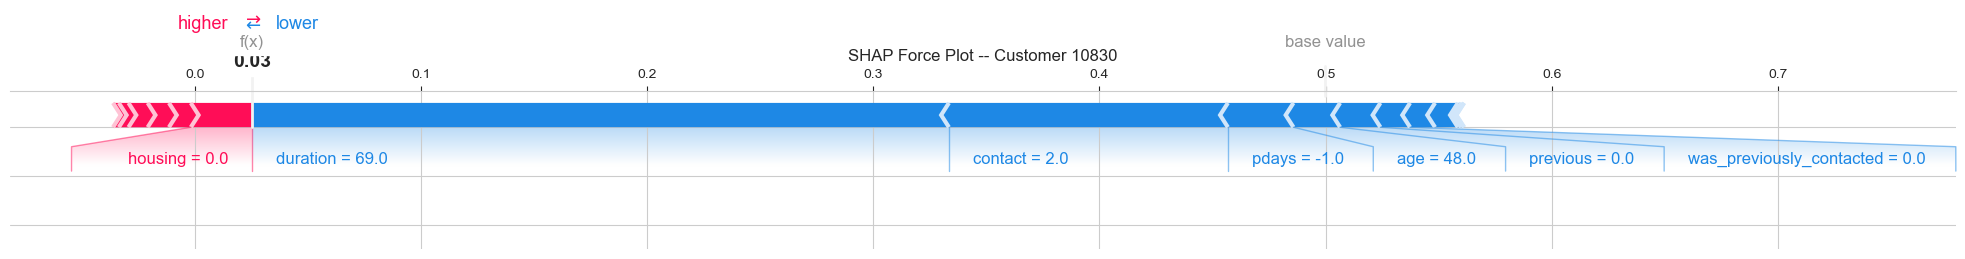

In [29]:
# --- Explain 5 individual predictions ---
five_idx = X_test_sample.index[:5]

for i, idx in enumerate(five_idx):
    row_pos = X_test_sample.index.get_loc(idx)
    pred_proba = rf.predict_proba(X_test.loc[[idx]])[0, 1]
    actual = y_test.loc[idx]

    print(f"\n--- Prediction #{i+1} (customer index {idx}) ---")
    print(f"Predicted probability of subscribing: {pred_proba:.3f}")
    print(f"Actual outcome: {'yes' if actual == 1 else 'no'}")

    plt.figure()
    shap.force_plot(
        expected_value,
        shap_values_pos[row_pos, :],
        X_test_sample.loc[idx],
        matplotlib=True,
        show=False
    )
    plt.title(f'SHAP Force Plot -- Customer {idx}')
    plt.tight_layout()
    plt.show()


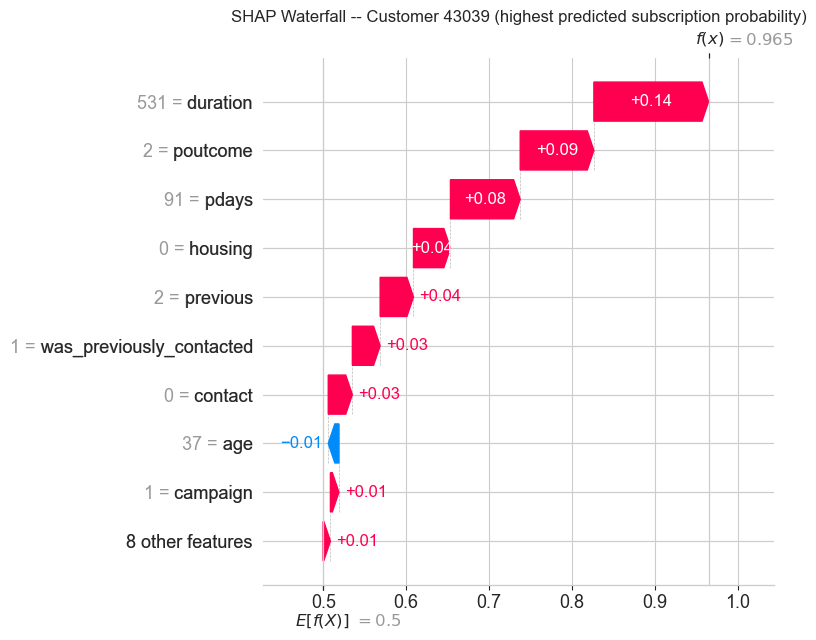

In [30]:
# A waterfall plot for the single highest-confidence "yes" prediction in our sample,
# which is often the most intuitive way to read an individual explanation.
best_idx_pos = np.argmax(rf.predict_proba(X_test_sample)[:, 1])
best_idx = X_test_sample.index[best_idx_pos]

explanation = shap.Explanation(
    values=shap_values_pos[best_idx_pos],
    base_values=expected_value,
    data=X_test_sample.loc[best_idx].values,
    feature_names=X_test_sample.columns.tolist()
)

shap.plots.waterfall(explanation, show=False)
plt.title(f'SHAP Waterfall -- Customer {best_idx} (highest predicted subscription probability)')
plt.tight_layout()
plt.show()


## 10. Conclusion & Insights

**Model performance**
- The **Random Forest** model outperformed **Logistic Regression** on both F1-score and
  ROC-AUC, indicating that the relationship between customer attributes and subscription
  is non-linear and benefits from an ensemble tree model.
- Both models struggle with precision on the minority ("yes") class due to natural class
  imbalance (~88% no / ~12% yes) — this is expected and was mitigated with
  `class_weight='balanced'` rather than naive resampling.

**Key predictive drivers** (from feature importance + SHAP)
- `duration` (last contact call length) is overwhelmingly the strongest predictor —
  longer calls correlate strongly with subscription. **Caveat:** this value is only known
  *after* a call completes, so it can't be used to *decide who to call* in advance; it's
  more useful for post-call quality scoring or as a benchmark upper bound on model
  performance.
- `month`, `poutcome` (outcome of a previous campaign), `contact` (contact type), `pdays`,
  and `housing` (existing housing loan) are consistently among the top drivers of
  subscription likelihood.
- Customers previously contacted with a successful prior outcome (`poutcome = success`)
  are substantially more likely to subscribe again — repeat engagement matters.

**Business recommendations**
- Prioritize re-contacting customers with a history of positive campaign outcomes.
- Time campaigns around the months that historically show higher subscription rates.
- Use the model's predicted probability to rank leads and focus call-center effort on the
  top-scoring segment rather than calling the full customer base, reducing cost per
  acquisition.
- If a pre-call targeting model is needed in production, retrain **without** `duration`
  (since it isn't available before the call) to get a realistic, deployable estimate of
  model performance.

**Skills demonstrated:** classification modeling, categorical feature encoding, model
evaluation (confusion matrix, F1-score, ROC/AUC), and model interpretability using SHAP.
